# 1. Load functions and data

In [3]:
import pandas as pd 
df = pd.read_csv('university_pcard_transactions.csv')
display(df.info(), df.head)

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    100 non-null    str    
 1   Transaction_Date  100 non-null    str    
 2   Cardholder_Name   100 non-null    str    
 3   Department        100 non-null    str    
 4   Merchant_Name     100 non-null    str    
 5   Expense_Category  100 non-null    str    
 6   MCC               100 non-null    int64  
 7   Amount_USD        100 non-null    float64
 8   Approval_Status   100 non-null    str    
dtypes: float64(1), int64(1), str(7)
memory usage: 16.5 KB

None

<bound method NDFrame.head of    Transaction_ID Transaction_Date  Cardholder_Name                Department  \
0    TXN-3E3E181C       2026-02-11        David Lee    College of Engineering   
1    TXN-ACE72C04       2025-09-27  Dr. Alice Smith     Computer Science Dept   
2    TXN-E383182C       2025-10-26        David Lee  Department of Psychology   
3    TXN-99ED6EBF       2026-01-29      Liam Neeson   Facilities & Operations   
4    TXN-12D1404E       2025-11-27      Bob Johnson     Computer Science Dept   
..            ...              ...              ...                       ...   
95   TXN-A300F4D5       2025-09-30    Olivia Benson      Athletics Department   
96   TXN-442D488B       2026-01-26      Bob Johnson   Administrative Services   
97   TXN-F68AE390       2026-02-24     Noah Bennett   Administrative Services   
98   TXN-33DC315B       2025-10-01       Karen Page        University Library   
99   TXN-E4EBAC52       2025-09-18     Noah Bennett  Department of Psychology  

# 2. Summarize expenditures for each department and expense category and visualize them

In [32]:
de_sum = df.pivot_table(
    index="Department", columns="Expense_Category", values="Amount_USD", aggfunc="sum", fill_value=0
)
de_sum

Expense_Category,Facilities & Maintenance,Food & Catering,IT & Software,Lab Supplies,Office Supplies,Travel & Transport
Department,,,,,,
Administrative Services,0.00,930.88,729.33,1584.82,283.48,1653.19
Athletics Department,434.41,417.77,1541.07,2067.06,730.81,0.00
College of Engineering,523.57,796.01,3668.30,1347.71,0.00,0.00
Computer Science Dept,378.36,270.84,655.77,478.47,399.18,0.00
Department of Biology,568.34,209.45,0.00,4244.71,108.50,0.00
Department of Chemistry,215.93,748.25,0.00,1398.12,67.72,1144.51
Department of Psychology,294.43,0.00,0.00,1566.35,782.06,0.00
Facilities & Operations,603.68,425.91,3870.57,3651.71,486.23,4265.21
School of Nursing,572.57,0.00,6821.11,1137.03,569.44,920.75


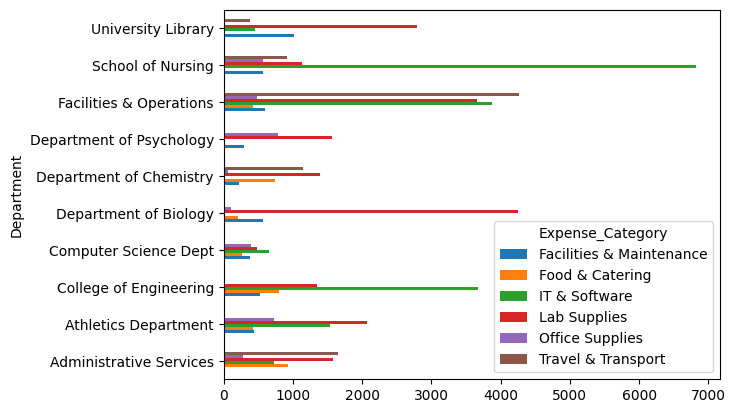

In [10]:
de_sum.plot.barh();

# 3. Group the departments into 2 clusters based on the total amount that they spend in each department

In [25]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
X = MinMaxScaler().set_output(transform="pandas").fit_transform(de_sum) 
k_cluster = KMeans(n_clusters=2).fit(X)

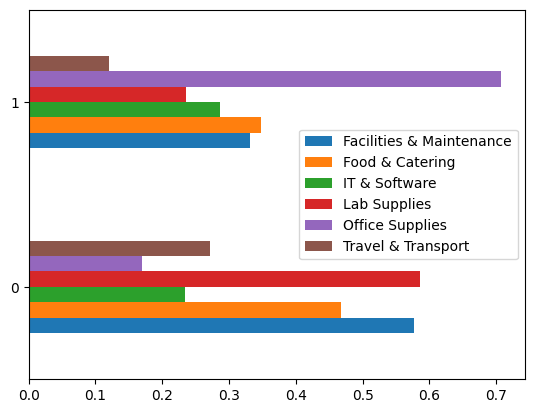

In [27]:
pd.DataFrame(k_cluster.cluster_centers_, 
            columns=X.columns).plot.barh();

# 4. Display a heatmap of the summary information

In [35]:
de_sum['cluster'] = k_cluster.labels_
de_sum.sort_values('cluster').style.background_gradient().format('${:.0f}', subset=de_sum.columns[:-1])

Expense_Category,Facilities & Maintenance,Food & Catering,IT & Software,Lab Supplies,Office Supplies,Travel & Transport,cluster
Department,,,,,,,
College of Engineering,$524,$796,$3668,$1348,$0,$0,0
Department of Biology,$568,$209,$0,$4245,$108,$0,0
Department of Chemistry,$216,$748,$0,$1398,$68,$1145,0
Facilities & Operations,$604,$426,$3871,$3652,$486,$4265,0
University Library,$1013,$0,$457,$2788,$0,$379,0
Administrative Services,$0,$931,$729,$1585,$283,$1653,1
Athletics Department,$434,$418,$1541,$2067,$731,$0,1
Computer Science Dept,$378,$271,$656,$478,$399,$0,1
Department of Psychology,$294,$0,$0,$1566,$782,$0,1


# 5. Create three clusters, a horizontal bar chart, and a heatmap